# ECG Arrhythmia Classification
**MIT-BIH Dataset | ANN vs 1D-CNN vs LSTM | MLflow Experiment Tracking**

This notebook:
1. Loads raw ECG signals from MIT-BIH using `wfdb`
2. Denoises using Discrete Wavelet Transform (DWT)
3. Handles class imbalance with SMOTE + undersampling
4. Trains and compares 3 architectures: ANN, 1D-CNN, LSTM
5. Tracks all experiments with MLflow
6. Evaluates with confusion matrix + per-class F1 scores

## 1. Install Dependencies

In [ ]:
pip install --upgrade pip

In [1]:
!pip install wfdb PyWavelets imbalanced-learn tensorflow mlflow scikit-learn seaborn --quiet

## 2. Load MIT-BIH ECG Data

In [3]:
import numpy as np
import wfdb

records = ['100', '101', '102', '103', '104', '105', '106', '107', '108', '109',
           '111', '112', '113', '114', '115', '116', '117', '118', '119', '121',
           '122', '123', '124', '200', '201', '202', '203', '205', '207', '208',
           '209', '210', '212', '213', '214', '215', '217', '219', '220', '221',
           '222', '223', '228', '230', '231', '232', '233', '234']

valid_types = ['A', 'E', 'F', 'J', 'L', 'N', 'Q', 'R', 'S', 'V', 'a', 'e', 'f', 'j', 'x']

X = []
y = []
window = int(0.5 * 360)  # 180 samples each side = 360 total per beat

for rec in records:
    record = wfdb.rdrecord(f'data/mitdb_full/{rec}')
    annotation = wfdb.rdann(f'data/mitdb_full/{rec}', 'atr')
    signal = record.p_signal[:, 0]

    for i, r in enumerate(annotation.sample):
        if r - window < 0 or r + window > len(signal):
            continue
        segment = signal[r - window : r + window]
        label = annotation.symbol[i]
        if label in valid_types:
            X.append(segment)
            y.append(label)

X = np.array(X)
y = np.array(y)
print(f"Loaded {X.shape[0]} beats, each of length {X.shape[1]}")
print(f"Classes found: {np.unique(y)}")

Loaded 102608 beats, each of length 360
Classes found: ['A' 'E' 'F' 'J' 'L' 'N' 'Q' 'R' 'S' 'V' 'a' 'e' 'f' 'j' 'x']


## 3. Explore Class Distribution

Class distribution (raw):
  N: 75011
  L: 8071
  R: 7255
  V: 7129
  A: 2546
  f: 982
  F: 802
  j: 229
  x: 193
  a: 150
  E: 106
  J: 83
  Q: 33
  e: 16
  S: 2


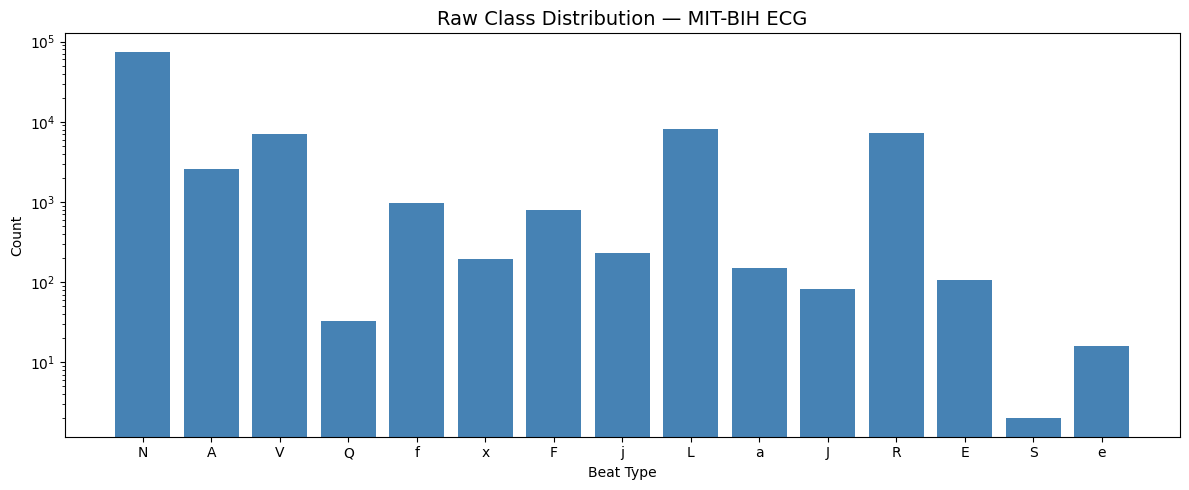


Note: Massive imbalance — N dominates. Will address with SMOTE + undersampling.


In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

counts = Counter(y)
print("Class distribution (raw):")
for cls, cnt in sorted(counts.items(), key=lambda x: -x[1]):
    print(f"  {cls}: {cnt}")

plt.figure(figsize=(12, 5))
plt.bar(counts.keys(), counts.values(), color='steelblue')
plt.title('Raw Class Distribution — MIT-BIH ECG', fontsize=14)
plt.xlabel('Beat Type')
plt.ylabel('Count')
plt.yscale('log')  # log scale of especially class "N" to show rare classes
plt.tight_layout()
plt.savefig('class_distribution_raw.png', dpi=150)
plt.show()
print("\nNote: Massive imbalance — N dominates. Will address with SMOTE + undersampling.") #dataset is massively skewed here

## 4. DWT Denoising
Discrete Wavelet Transform separates the ECG signal into frequency bands. High-frequency detail coefficients (cD1–cD4) carry most of the noise and are soft-thresholded.

/Users/nischithajayaraj/miniconda3/lib/python3.11/site-packages/pywt/_multilevel.py:43: UserWarning: Level value of 7 is too high: all coefficients will experience boundary effects.
  warnings.warn(


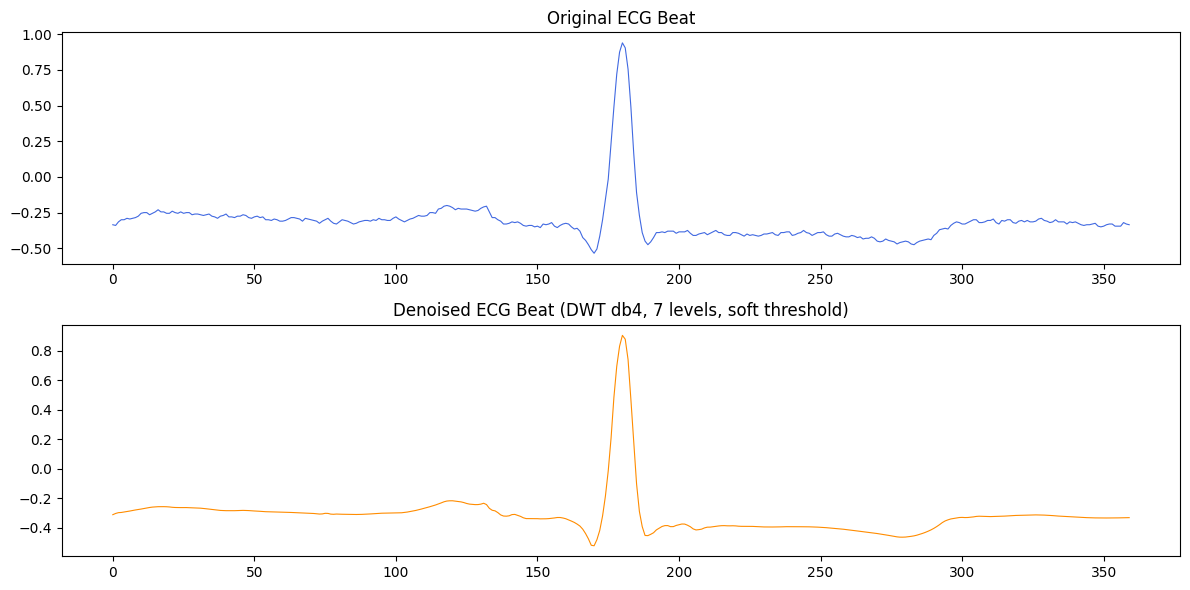

In [5]:
import pywt

def dwt_denoise(signals, wavelet='db4', levels=7):
    coeffs = pywt.wavedec(signals, wavelet, level=levels)
    sigma = np.median(np.abs(coeffs[-1])) / 0.6745 #0.6745 is a statistical constant that converts median absolute deviation into a standard deviation estimate. 
    #So sigma = estimated noise level.
    # threshold Calculates the cutoff value — anything below this is considered noise. 
    #signals.shape[1] = 360 (the length of each beat). This is the standard Donoho-Johnstone universal threshold formula — a well-known formula in signal processing.
    threshold = sigma * np.sqrt(2 * np.log(signals.shape[1]))
    #actual denoising step
    coeffs_thresh = [coeffs[0]] + [
        pywt.threshold(c, threshold, mode='soft') for c in coeffs[1:]
    ]
    denoised = pywt.waverec(coeffs_thresh, wavelet)
    # waverec may add 1 sample — trim back to original length
    return denoised[:, :signals.shape[1]]
#running the denoising on all the 102608 beats at once
X_denoised = dwt_denoise(X)

# Visualize one beat before/after
fig, axes = plt.subplots(2, 1, figsize=(12, 6))
axes[0].plot(X[0], color='royalblue', linewidth=0.8) #blue is the original
axes[0].set_title('Original ECG Beat', fontsize=12)
axes[1].plot(X_denoised[0], color='darkorange', linewidth=0.8) #after denoising
axes[1].set_title('Denoised ECG Beat (DWT db4, 7 levels, soft threshold)', fontsize=12)
plt.tight_layout()
plt.savefig('dwt_denoising.png', dpi=150)
plt.show()

## 5. Label Encoding + Class Filtering

In [6]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_encoded = le.fit_transform(y)
#SMOTE (Synthetic Minority Over-sampling Technique) is used in machine learning when your dataset is imbalanced.
# Filter out classes with fewer than 6 samples (SMOTE needs k_neighbors=5 minimum)
valid_classes = [cls for cls, count in Counter(y_encoded).items() if count >= 6]
valid_mask = np.isin(y_encoded, valid_classes)
X_filtered = X_denoised[valid_mask]
y_filtered = y_encoded[valid_mask]

# Re-encode so labels are consecutive
y_filtered = LabelEncoder().fit_transform(y_filtered)
n_classes = len(np.unique(y_filtered))

print(f"After filtering: {X_filtered.shape[0]} samples, {n_classes} classes")
print(f"Class distribution: {Counter(y_filtered)}")

After filtering: 102606 samples, 14 classes
Class distribution: Counter({np.int64(5): 75011, np.int64(4): 8071, np.int64(7): 7255, np.int64(8): 7129, np.int64(0): 2546, np.int64(11): 982, np.int64(2): 802, np.int64(12): 229, np.int64(13): 193, np.int64(9): 150, np.int64(1): 106, np.int64(3): 83, np.int64(6): 33, np.int64(10): 16})


## 6. Handle Class Imbalance — SMOTE + Undersampling
Strategy:
- **SMOTE**: oversample minority classes synthetically
- **Undersample N**: cap the dominant Normal class to avoid it drowning others

In [7]:
import random
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split

random.seed(42)
np.random.seed(42)

# Reshape to 2D for SMOTE
X_2d = X_filtered.reshape(X_filtered.shape[0], -1)

print("Applying SMOTE...")
X_smote, y_smote = SMOTE(random_state=42, k_neighbors=5).fit_resample(X_2d, y_filtered)
print(f"After SMOTE: {X_smote.shape[0]} samples")

# Find the dominant class (N) and undersample it
class_counts = Counter(y_smote)
dominant_class = max(class_counts, key=class_counts.get)
target_n = min(50000, class_counts[dominant_class])

dom_indices = np.where(y_smote == dominant_class)[0]
other_indices = np.where(y_smote != dominant_class)[0]
sampled_dom = np.random.choice(dom_indices, target_n, replace=False)

final_indices = np.concatenate([sampled_dom, other_indices])
np.random.shuffle(final_indices)

X_balanced = X_smote[final_indices]
y_balanced = y_smote[final_indices]

print(f"After undersampling: {X_balanced.shape[0]} samples")
print(f"Final class distribution: {Counter(y_balanced)}")

# 60-20-20 split
X_train, X_temp, y_train, y_temp = train_test_split(
    X_balanced, y_balanced, test_size=0.4, random_state=42, stratify=y_balanced)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

print(f"\nTrain: {X_train.shape[0]} | Val: {X_val.shape[0]} | Test: {X_test.shape[0]}")

Applying SMOTE...
After SMOTE: 1050154 samples
After undersampling: 1025143 samples
Final class distribution: Counter({np.int64(12): 75011, np.int64(2): 75011, np.int64(0): 75011, np.int64(10): 75011, np.int64(7): 75011, np.int64(13): 75011, np.int64(9): 75011, np.int64(6): 75011, np.int64(4): 75011, np.int64(11): 75011, np.int64(3): 75011, np.int64(1): 75011, np.int64(8): 75011, np.int64(5): 50000})

Train: 615085 | Val: 205029 | Test: 205029


## 7. MLflow Setup

In [ ]:
import mlflow
import mlflow.tensorflow

mlflow.set_experiment("ecg-arrhythmia-classification")
print("MLflow experiment set. Run 'mlflow ui' in terminal to view results.")

## 8. Evaluation Helper — Confusion Matrix + Per-Class F1

In [ ]:
import tensorflow as tf
from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, accuracy_score
)

def evaluate_model(model, X_test, y_test, model_name, class_names=None):
    """Full evaluation: accuracy, per-class F1, confusion matrix."""
    y_pred_proba = model.predict(X_test, verbose=0)
    y_pred = np.argmax(y_pred_proba, axis=1)

    acc = accuracy_score(y_test, y_pred)
    f1_macro = f1_score(y_test, y_pred, average='macro')
    f1_weighted = f1_score(y_test, y_pred, average='weighted')

    print(f"\n{'='*50}")
    print(f"  {model_name} Results")
    print(f"{'='*50}")
    print(f"  Accuracy:        {acc:.4f}")
    print(f"  F1 (macro):      {f1_macro:.4f}")
    print(f"  F1 (weighted):   {f1_weighted:.4f}")
    print(f"\nPer-class report:")
    print(classification_report(y_test, y_pred, target_names=class_names))

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f'Confusion Matrix — {model_name}', fontsize=14)
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    cm_path = f'confusion_matrix_{model_name.lower().replace(" ", "_")}.png'
    plt.savefig(cm_path, dpi=150)
    plt.show()

    return acc, f1_macro, f1_weighted, cm_path

# Get class names for display
class_names = [str(c) for c in range(n_classes)]
print(f"Ready to evaluate {n_classes} classes.")

## 9. Architecture 1 — ANN (Feedforward Neural Network)
Baseline model. Input: flat 360-feature vector.

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

# ANN takes flat (360,) input
X_train_flat = X_train.reshape(-1, 360)
X_val_flat   = X_val.reshape(-1, 360)
X_test_flat  = X_test.reshape(-1, 360)

def build_ann(n_classes):
    model = tf.keras.Sequential([
        tf.keras.layers.Dense(256, activation='relu', input_shape=(360,)),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.Dense(n_classes, activation='softmax')
    ], name='ANN')
    return model

EPOCHS = 50
BATCH_SIZE = 64
LR = 0.001

with mlflow.start_run(run_name="ANN"):
    mlflow.log_params({
        "architecture": "ANN",
        "layers": "256-128-64",
        "dropout": 0.3,
        "batch_norm": True,
        "optimizer": "adam",
        "learning_rate": LR,
        "batch_size": BATCH_SIZE,
        "epochs": EPOCHS,
        "imbalance_handling": "SMOTE + undersample",
        "denoising": "DWT db4 level7 soft-threshold"
    })

    ann = build_ann(n_classes)
    ann.compile(
        optimizer=tf.keras.optimizers.Adam(LR),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    ann.summary()

    early_stop = EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)

    history_ann = ann.fit(
        X_train_flat, y_train,
        validation_data=(X_val_flat, y_val),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=[early_stop],
        verbose=1
    )

    acc_ann, f1_ann, f1w_ann, cm_ann = evaluate_model(
        ann, X_test_flat, y_test, "ANN", class_names)

    mlflow.log_metrics({
        "test_accuracy": acc_ann,
        "test_f1_macro": f1_ann,
        "test_f1_weighted": f1w_ann
    })
    mlflow.log_artifact(cm_ann)
    ann.save('model_ann.h5')
    mlflow.log_artifact('model_ann.h5')

print("ANN training complete and logged to MLflow.")

## 10. Architecture 2 — 1D-CNN
Convolutional layers extract local temporal features from the raw waveform — well-suited for ECG.

In [ ]:
# CNN takes (360, 1) input
X_train_3d = X_train.reshape(-1, 360, 1)
X_val_3d   = X_val.reshape(-1, 360, 1)
X_test_3d  = X_test.reshape(-1, 360, 1)

def build_cnn(n_classes):
    model = tf.keras.Sequential([
        tf.keras.layers.Conv1D(64, kernel_size=5, activation='relu', input_shape=(360, 1)),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling1D(pool_size=2),
        tf.keras.layers.Conv1D(128, kernel_size=5, activation='relu'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling1D(pool_size=2),
        tf.keras.layers.Conv1D(256, kernel_size=3, activation='relu'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.GlobalAveragePooling1D(),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dropout(0.4),
        tf.keras.layers.Dense(n_classes, activation='softmax')
    ], name='CNN_1D')
    return model

with mlflow.start_run(run_name="1D-CNN"):
    mlflow.log_params({
        "architecture": "1D-CNN",
        "filters": "64-128-256",
        "kernel_sizes": "5-5-3",
        "pooling": "MaxPool + GlobalAvgPool",
        "dropout": 0.4,
        "optimizer": "adam",
        "learning_rate": LR,
        "batch_size": BATCH_SIZE,
        "epochs": EPOCHS,
        "imbalance_handling": "SMOTE + undersample",
        "denoising": "DWT db4 level7 soft-threshold"
    })

    cnn = build_cnn(n_classes)
    cnn.compile(
        optimizer=tf.keras.optimizers.Adam(LR),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    cnn.summary()

    history_cnn = cnn.fit(
        X_train_3d, y_train,
        validation_data=(X_val_3d, y_val),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=[EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)],
        verbose=1
    )

    acc_cnn, f1_cnn, f1w_cnn, cm_cnn = evaluate_model(
        cnn, X_test_3d, y_test, "1D-CNN", class_names)

    mlflow.log_metrics({
        "test_accuracy": acc_cnn,
        "test_f1_macro": f1_cnn,
        "test_f1_weighted": f1w_cnn
    })
    mlflow.log_artifact(cm_cnn)
    cnn.save('model_cnn.h5')
    mlflow.log_artifact('model_cnn.h5')

print("1D-CNN training complete and logged to MLflow.")

## 11. Architecture 3 — LSTM
LSTM captures long-range temporal dependencies in the ECG sequence — relevant for rhythm-based arrhythmias.

In [ ]:
# LSTM also takes (360, 1)
def build_lstm(n_classes):
    model = tf.keras.Sequential([
        tf.keras.layers.LSTM(64, return_sequences=True, input_shape=(360, 1)),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.LSTM(128, return_sequences=False),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.Dense(n_classes, activation='softmax')
    ], name='LSTM')
    return model

with mlflow.start_run(run_name="LSTM"):
    mlflow.log_params({
        "architecture": "LSTM",
        "lstm_units": "64-128",
        "dropout": 0.3,
        "optimizer": "adam",
        "learning_rate": LR,
        "batch_size": BATCH_SIZE,
        "epochs": EPOCHS,
        "imbalance_handling": "SMOTE + undersample",
        "denoising": "DWT db4 level7 soft-threshold"
    })

    lstm = build_lstm(n_classes)
    lstm.compile(
        optimizer=tf.keras.optimizers.Adam(LR),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    lstm.summary()

    history_lstm = lstm.fit(
        X_train_3d, y_train,
        validation_data=(X_val_3d, y_val),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=[EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)],
        verbose=1
    )

    acc_lstm, f1_lstm, f1w_lstm, cm_lstm = evaluate_model(
        lstm, X_test_3d, y_test, "LSTM", class_names)

    mlflow.log_metrics({
        "test_accuracy": acc_lstm,
        "test_f1_macro": f1_lstm,
        "test_f1_weighted": f1w_lstm
    })
    mlflow.log_artifact(cm_lstm)
    lstm.save('model_lstm.h5')
    mlflow.log_artifact('model_lstm.h5')

print("LSTM training complete and logged to MLflow.")

## 12. Training History — Loss & Accuracy Curves

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for hist, label, color in [
    (history_ann, 'ANN', 'royalblue'),
    (history_cnn, '1D-CNN', 'darkorange'),
    (history_lstm, 'LSTM', 'forestgreen')
]:
    axes[0].plot(hist.history['val_loss'], label=label, color=color)
    axes[1].plot(hist.history['val_accuracy'], label=label, color=color)

axes[0].set_title('Validation Loss', fontsize=13)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].set_title('Validation Accuracy', fontsize=13)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.suptitle('Training Curves — ANN vs 1D-CNN vs LSTM', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150)
plt.show()

## 13. Final Results Summary

In [ ]:
import pandas as pd

results = pd.DataFrame({
    'Model':       ['ANN', '1D-CNN', 'LSTM'],
    'Accuracy':    [acc_ann, acc_cnn, acc_lstm],
    'F1 (macro)':  [f1_ann, f1_cnn, f1_lstm],
    'F1 (weighted)': [f1w_ann, f1w_cnn, f1w_lstm]
})
results = results.sort_values('F1 (macro)', ascending=False).reset_index(drop=True)
results[['Accuracy', 'F1 (macro)', 'F1 (weighted)']] = \
    results[['Accuracy', 'F1 (macro)', 'F1 (weighted)']].applymap(lambda x: f"{x:.4f}")

print("\n===== Final Model Comparison =====")
print(results.to_string(index=False))

# Bar chart comparison
fig, ax = plt.subplots(figsize=(9, 5))
models = ['ANN', '1D-CNN', 'LSTM']
x = np.arange(len(models))
w = 0.25
ax.bar(x - w, [acc_ann, acc_cnn, acc_lstm], w, label='Accuracy', color='steelblue')
ax.bar(x,     [f1_ann, f1_cnn, f1_lstm],   w, label='F1 Macro', color='darkorange')
ax.bar(x + w, [f1w_ann, f1w_cnn, f1w_lstm], w, label='F1 Weighted', color='forestgreen')
ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=12)
ax.set_ylim(0, 1.05)
ax.set_ylabel('Score')
ax.set_title('Model Comparison — ECG Arrhythmia Classification', fontsize=13)
ax.legend()
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150)
plt.show()

## 14. Key Takeaways

- **DWT denoising** preserves clinically relevant morphological features while suppressing baseline wander and high-frequency noise
- **Class imbalance** is a real challenge in the MIT-BIH dataset (N class dominates). SMOTE + undersampling creates a more balanced training set, but per-class F1 scores are the honest metric — not overall accuracy
- **1D-CNN** is expected to outperform ANN on raw ECG waveforms because convolutional filters naturally learn local patterns (P-wave, QRS complex, T-wave) without manual feature engineering
- **LSTM** captures temporal dependencies across the beat sequence but is slower to train
- All experiments tracked in **MLflow** for reproducibility and comparison

Run `mlflow ui` in terminal to explore experiment results interactively.